<a href="https://colab.research.google.com/github/Adhiaris/midterm-machine-learning/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q optuna mlflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import optuna
import mlflow
import mlflow.sklearn

import tensorflow as tf
from tensorflow import keras


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88

In [ ]:
import pandas as pd

df = pd.read_csv('clusteringmidterm.csv')


In [ ]:
df_clean = df.drop(columns=['CUST_ID'], errors='ignore')

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(df_clean)

Q1 = np.percentile(X_imp, 25, axis=0)
Q3 = np.percentile(X_imp, 75, axis=0)
IQR = Q3 - Q1
mask = ~((X_imp < (Q1 - 1.5 * IQR)) | (X_imp > (Q3 + 1.5 * IQR))).any(axis=1)
X_clean = X_imp[mask]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)


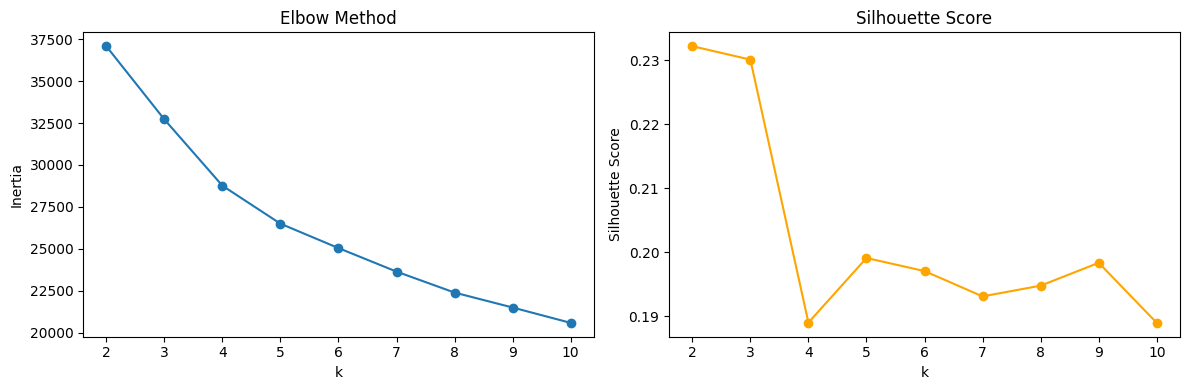

In [ ]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(list(K_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score')
plt.tight_layout(); plt.show()


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    k = trial.suggest_int('n_clusters', 2, 10)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    return silhouette_score(X_scaled, km.fit_predict(X_scaled))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_k = study.best_params['n_clusters']
print(f"Best k: {best_k}, Silhouette: {study.best_value:.4f}")


Best k: 2, Silhouette: 0.2322


## Machine Learning Model

In [ ]:
mlflow.set_experiment("midterm-clustering")

with mlflow.start_run(run_name="KMeans"):
    km_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    km_labels = km_model.fit_predict(X_scaled)

    km_sil = silhouette_score(X_scaled, km_labels)
    mlflow.log_param("model", "KMeans")
    mlflow.log_param("n_clusters", best_k)
    mlflow.log_metric("silhouette_score", km_sil)
    mlflow.log_metric("inertia", km_model.inertia_)

print(f"[KMeans] Silhouette: {km_sil:.4f} | Inertia: {km_model.inertia_:.2f}")


2026/05/16 03:54:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/16 03:54:59 INFO mlflow.store.db.utils: Updating database tables
2026/05/16 03:55:01 INFO mlflow.tracking.fluent: Experiment with name 'midterm-clustering' does not exist. Creating a new experiment.


[KMeans] Silhouette: 0.2322 | Inertia: 37086.33


## Deep Learning Model

In [ ]:
input_dim = X_scaled.shape[1]
encoding_dim = 8

inputs = keras.Input(shape=(input_dim,))
encoded = keras.layers.Dense(16, activation='relu')(inputs)
encoded = keras.layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = keras.layers.Dense(16, activation='relu')(encoded)
decoded = keras.layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = keras.Model(inputs, decoded)
encoder = keras.Model(inputs, encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=64, validation_split=0.1, verbose=0)

X_encoded = encoder.predict(X_scaled, verbose=0)

with mlflow.start_run(run_name="Autoencoder+KMeans"):
    ae_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    ae_labels = ae_km.fit_predict(X_encoded)

    ae_sil = silhouette_score(X_encoded, ae_labels)
    mlflow.log_param("model", "Autoencoder+KMeans")
    mlflow.log_param("n_clusters", best_k)
    mlflow.log_param("encoding_dim", encoding_dim)
    mlflow.log_metric("silhouette_score", ae_sil)

print(f"[Autoencoder+KMeans] Silhouette: {ae_sil:.4f}")


[Autoencoder+KMeans] Silhouette: 0.4346


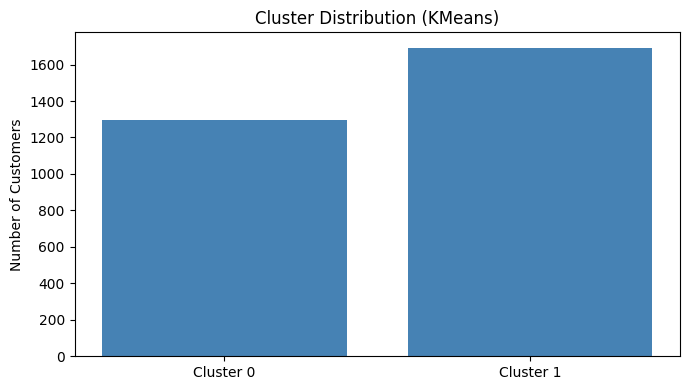

In [ ]:
unique, counts = np.unique(km_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([f'Cluster {i}' for i in unique], counts, color='steelblue')
plt.title('Cluster Distribution (KMeans)')
plt.ylabel('Number of Customers')
plt.tight_layout(); plt.show()


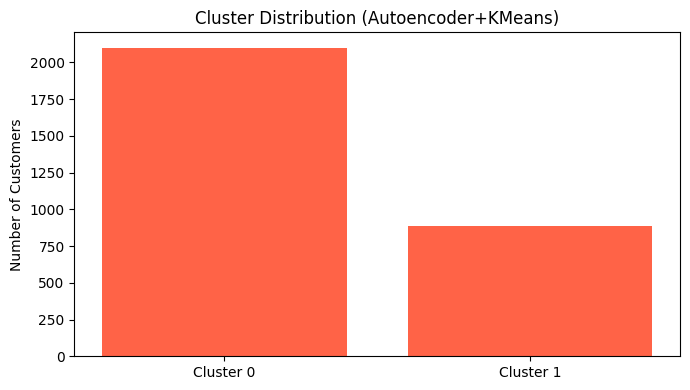

In [ ]:
unique, counts = np.unique(ae_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([f'Cluster {i}' for i in unique], counts, color='tomato')
plt.title('Cluster Distribution (Autoencoder+KMeans)')
plt.ylabel('Number of Customers')
plt.tight_layout(); plt.show()


In [ ]:
df_result = pd.DataFrame(X_clean, columns=df_clean.columns)
df_result['Cluster'] = km_labels
df_result.groupby('Cluster').mean().round(2)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,900.42,0.97,711.00,344.98,366.59,150.47,0.75,0.19,0.62,0.04,0.68,15.17,3429.74,837.71,416.22,0.05,12.0
1,1432.46,0.98,119.81,88.96,30.86,621.69,0.12,0.06,0.06,0.15,2.62,1.89,3015.81,797.69,499.26,0.01,12.0


In [ ]:
df_result2 = pd.DataFrame(X_clean, columns=df_clean.columns)
df_result2['Cluster'] = ae_labels
df_result2.groupby('Cluster').mean().round(2)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1189.91,1.00,229.75,123.71,106.39,332.98,0.32,0.09,0.24,0.1,1.70,5.58,2861.5,587.52,454.53,0.02,12.0
1,1230.32,0.93,722.66,380.50,342.16,617.79,0.56,0.18,0.44,0.1,1.96,12.55,3986.1,1354.30,484.00,0.06,12.0


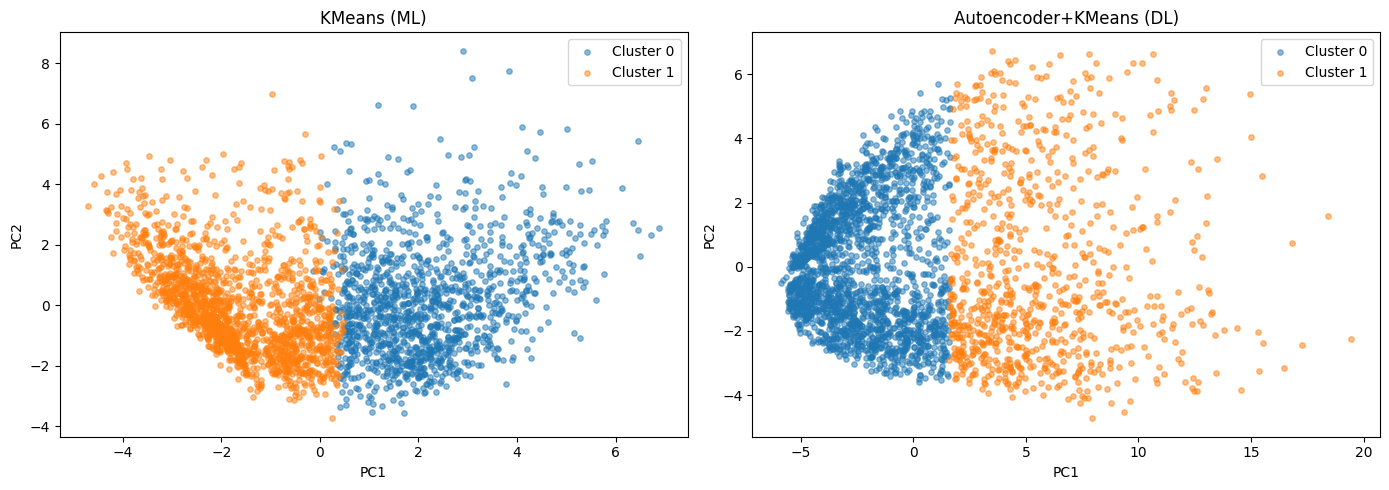

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca_enc = PCA(n_components=2).fit_transform(X_encoded)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(best_k):
    axes[0].scatter(X_pca[km_labels==c, 0], X_pca[km_labels==c, 1], label=f'Cluster {c}', alpha=0.5, s=15)
axes[0].set_title('KMeans (ML)'); axes[0].legend(); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

for c in range(best_k):
    axes[1].scatter(X_pca_enc[ae_labels==c, 0], X_pca_enc[ae_labels==c, 1], label=f'Cluster {c}', alpha=0.5, s=15)
axes[1].set_title('Autoencoder+KMeans (DL)'); axes[1].legend(); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout(); plt.show()
